# **Project Overview**
Hello, on this project i try to learn about *"How to cleaning dan preparing data"* for analytical purposes. I use ***Netflix Movies and TV Shows dataset*** that i got from Kaggle.

## **Projects Objectives**

- Understand the dataset structure
- Identify data quality issues
- Handle missing values
- Remove duplicate records
- Convert incorrect data types
- Standardize categorical values
- Prepare clean dataset for analysis

## **Technologies Used**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## **Dataset Information**

| Information | Details |
|---|---|
| Dataset Name | Netflix Movies and TV Shows |
| Source | Kaggle |
| Format | CSV |
| Total Rows | 8807 |
| Total Columns | 12 |


# Section 1 : **Preparing Data**

This section prepares the dataset by importing libraries, loading the CSV file, and initializing the project environment.

In [1]:
import kagglehub
path = kagglehub.dataset_download("shivamb/netflix-shows")

Using Colab cache for faster access to the 'netflix-shows' dataset.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(path + "/netflix_titles.csv")

# Section 2 : **Initial Data Exploration**

This section aims to understand the overall structure of the dataset before starting the cleaning process.

## Display Dataset

In [3]:
# ======================
# Display 4 Initial data
# ======================

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Check Dataset Information

In [4]:
# ===================
# Check Dataset Shape
# ===================

print(f"Data Information : {df.shape[0]} rows & {df.shape[1]} columns")

Data Information : 8807 rows & 12 columns


In [5]:
# ========================
# Check Column Information
# ========================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
# ===================
# Statistical Summary
# ===================

df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
# ====================
# Check Missing Values
# ====================

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:
# ===============================
# Check Missing Values Percentage
# ===============================

df.isnull().sum()/df.shape[0]*100

,0
show_id,0.000000
type,0.000000
title,0.000000
director,29.908028
cast,9.367549
country,9.435676
date_added,0.113546
release_year,0.000000
rating,0.045418
duration,0.034064


In [9]:
# =======================
# Check Duplicated Values
# =======================

df.duplicated().sum()

np.int64(0)

In [10]:
# ===================
# Check Unique Values
# ===================

for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: show_id
show_id
s8807    1
s1       1
s2       1
s3       1
s4       1
        ..
s12      1
s11      1
s10      1
s9       1
s8       1
Name: count, Length: 8807, dtype: int64

Column: type
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Column: title
title
Zubaan                                 1
Dick Johnson Is Dead                   1
Blood & Water                          1
Ganglands                              1
Jailbirds New Orleans                  1
                                      ..
Bangkok Breaking                       1
Vendetta: Truth, Lies and The Mafia    1
The Starling                           1
The Great British Baking Show          1
Sankofa                                1
Name: count, Length: 8807, dtype: int64

Column: director
director
Rajiv Chilaka              19
Raúl Campos, Jan Suter     18
Suhas Kadav                16
Marcus Raboy               16
Jay Karas                  14
                           ..
James Brown       

# Section 3 : **Data Cleaning**

This section focuses on improving data quality by
handling missing values, duplicates, inconsistent
formats, and incorrect data types.

## Remove Duplicate Data

In [11]:
# ========================
# Remove Duplicate Values
# ========================

df.drop_duplicates(inplace=True)

In [12]:
# ============================
# Check Duplicate Values Again
# ============================

df.duplicated().sum()

np.int64(0)

## Handle Missing Values

In [13]:
# ===================
# Fill Missing Values
# ===================

df = df.fillna({
    'director': 'Unknown',
    'cast': 'Unknown',
    'country': 'Unknown',
    'date_added': 'Unknown',
    'rating': 'NR',
    'duration': 'Unknown'
})


In [14]:
# ==========================
# Check Missing Values Again
# ==========================

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


**Notes** :

> In this dataset i don't found any critical null values that can be deleted, because all the columns in this dataset are considered important for the future analysis process



## Standardize Data Formatting

In [15]:
# ===================
# Remove Extra Spaces
# ===================

df['title'] = df['title'].str.strip()
df['director'] = df['director'].str.strip()
df['cast'] = df['cast'].str.strip()
df['country'] = df['country'].str.strip()
df['rating'] = df['rating'].str.strip()

In [16]:
# ====================
# Fix Misplaced Values
# ====================

misplaced_duration_mask = df['rating'].str.contains('min|Season', na=False)
df.loc[misplaced_duration_mask, 'duration'] = df.loc[misplaced_duration_mask, 'rating']
df.loc[misplaced_duration_mask, 'rating'] = 'NR'

**Notes :**

> During value inspection, several duration values such as "74 min" were incorrectly stored in the `rating` column. This issue indicates a data alignment inconsistency, therefore the affected values were reassigned to the correct column.



# Section 4 : **Data Transformation**

This section transforms the cleaned dataset into a more structured and analysis-ready format through datatype conversion, schema refinement, and feature generation.

## Convert Data Types

**Notes** :

> In this dataset has data_added that can be change the data type from Object to Datetime for better future analytics process



In [17]:
# ======================
# Change dtypes of data
# ======================

df['date_added'] = df['date_added'].str.strip() # to delete any formating teks issues on data (remove accidental extra spaces)
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y', errors='coerce') # correct text format and change to datetime type

## Rename Columns

**Notes :**

> Column names were renamed to improve readability, semantic clarity, and consistency throughout the project.

In [18]:
# ==============
# Rename Columns
# ==============

df = df.rename(columns={
    'show_id': 'content_id',
    'type': 'content_type',
    'listed_in': 'genre',
    'description': 'synopsis'
})

## Multi Value Handle

**Notes :**

> Many values ​​can have a significant impact on future processes, therefore I decided to convert it into a list so that it can be processed for analysis.

In [19]:
# ================================
# Change Multi Value become a List
# ================================

df['cast'] = df['cast'].str.split(', ').apply(
    lambda x: [i.strip() for i in x]
)

df['genre'] = df['genre'].str.split(', ').apply(
    lambda x: [i.strip() for i in x]
)

df['country'] = df['country'].str.split(', ').apply(
    lambda x: [i.strip() for i in x]
)

df['director'] = df['director'].str.split(', ').apply(
    lambda x: [i.strip() for i in x]
)

## Extract Temporal Features

**Notes :**

> Temporal features such as year and month were extracted from the `date_added` column to support time-based analysis, trend identification, and content growth exploration.

In [20]:
df['year_added'] = df['date_added'].dt.year.astype('Int64') # Extract Year
df['month_added'] = df['date_added'].dt.month_name() # Extract Month

df['month_added'] = df['month_added'].fillna('<NA>')

## Duration Transformation

**Notes :**

> The `duration` column originally contained text-based values such as "90 min" and "2 Seasons". Numeric extraction and transformation were performed to enable quantitative analysis and improve analytical flexibility.

In [21]:
df['duration_minutes'] = df[df['content_type'] == 'Movie']['duration'].str.extract('(\d+)')
df['duration_seasons'] = df[df['content_type'] == 'TV Show']['duration'].str.extract('(\d+)')

df = df.drop(columns=['duration'])

df['duration_minutes'] = df['duration_minutes'].fillna(0).astype(int)
df['duration_seasons'] = df['duration_seasons'].fillna(0).astype(int)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_40649/2873825872.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_minutes'] = df[df['content_type'] == 'Movie']['duration'].str.extract('(\d+)')
/tmp/ipykernel_40649/2873825872.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['duration_seasons'] = df[df['content_type'] == 'TV Show']['duration'].str.extract('(\d+)')


## Content-Based Features

**Notes :**

> Content ratings were grouped into broader audience categories
(Kids, Teens, and Adults) to simplify analysis and improve
readability during exploratory data analysis.

In [22]:
def group_rating(rating):
    if rating in ['G', 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'TV-G']:
        return 'Kids'
    elif rating in ['PG', 'PG-13', 'TV-PG', 'TV-14']:
        return 'Teens'
    elif rating in ['R', 'NC-17', 'TV-MA']:
        return 'Adults'
    else:
        return 'Unrated'

df['target_audience'] = df['rating'].apply(group_rating)

# Section 5 : **Exploratory Data Analysis (EDA)**

This section explores example trends, distributions, and patterns within the cleaned dataset through statistical analysis and visualization.

## Content Type Distribution

In [23]:
df['content_type'].value_counts()

,count
content_type,
Movie,6131
TV Show,2676


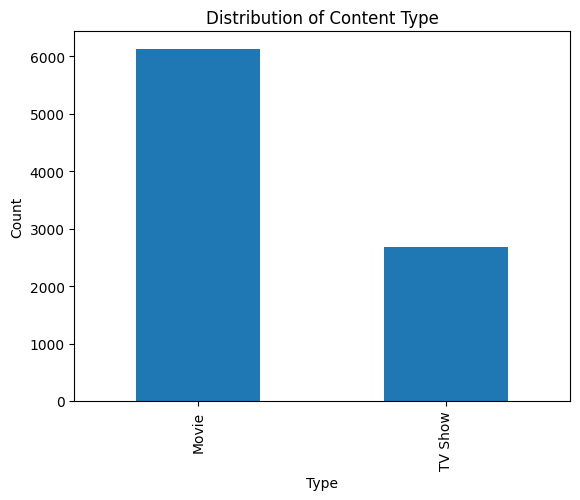

In [24]:
df['content_type'].value_counts().plot(kind='bar')

plt.title('Distribution of Content Type')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

## Top 10 Countries

In [25]:
top_10_country = (
    df
    .explode('country')['country']
    .value_counts()
    .head(10)
)

top_10_country

,count
country,
United States,3689
India,1046
Unknown,831
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231


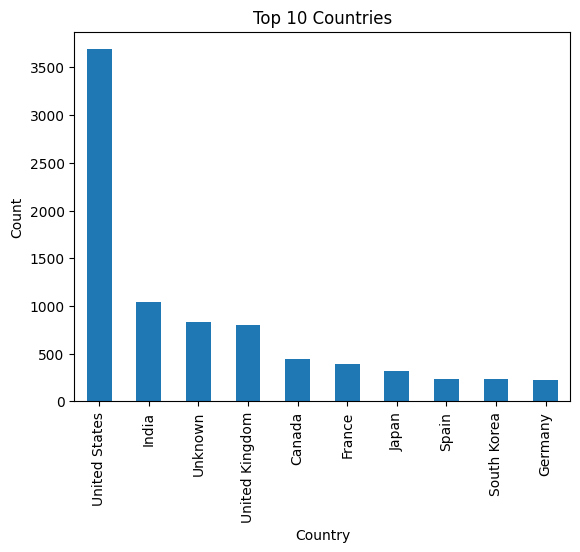

In [26]:
top_10_country.plot(kind='bar')

plt.title('Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Count')

plt.show()

## Content Release Trend

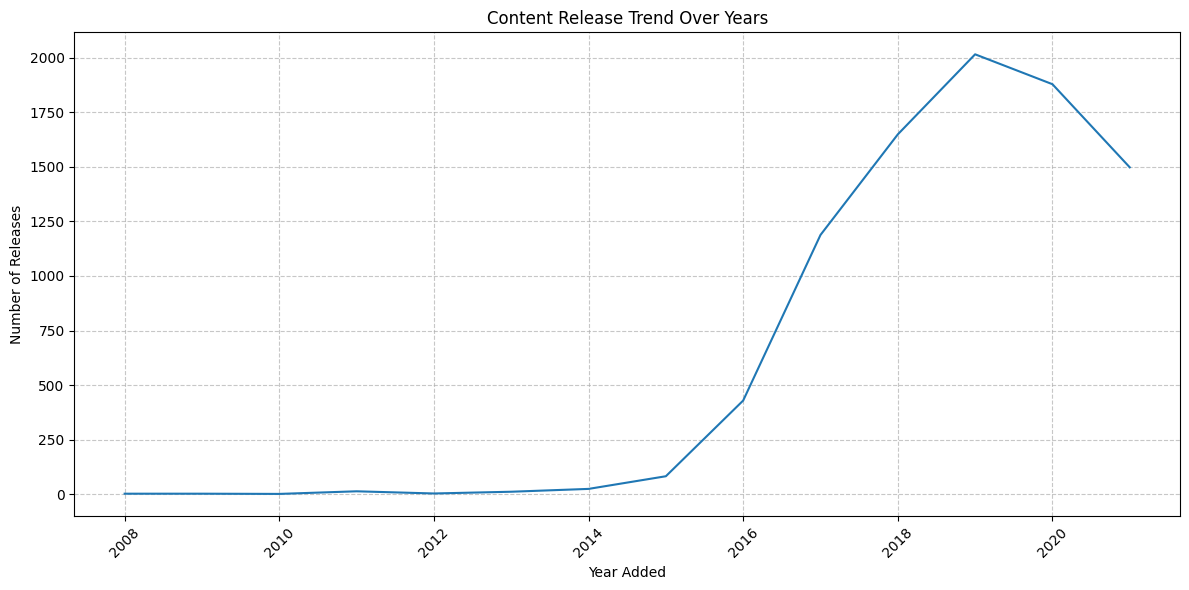

In [27]:
release_trend = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=release_trend.index, y=release_trend.values)
plt.title('Content Release Trend Over Years')
plt.xlabel('Year Added')
plt.ylabel('Number of Releases')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Section 6 : **Final Dataset Validation**

This section validates the final dataset structure, data types, and remaining data quality conditions after all preprocessing stages.

In [28]:
df.sample()

,content_id,content_type,title,director,cast,country,date_added,release_year,rating,genre,synopsis,year_added,month_added,duration_minutes,duration_seasons,target_audience
3808,s3809,TV Show,1994,[Diego Enrique Osorno],[Unknown],[Mexico],2019-05-17,2019,TV-MA,"[Crime TV Shows, Docuseries, International TV ...",Archival video and new interviews examine Mexi...,2019,May,0,1,Adults


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   content_id        8807 non-null   object        
 1   content_type      8807 non-null   object        
 2   title             8807 non-null   object        
 3   director          8807 non-null   object        
 4   cast              8807 non-null   object        
 5   country           8807 non-null   object        
 6   date_added        8797 non-null   datetime64[ns]
 7   release_year      8807 non-null   int64         
 8   rating            8807 non-null   object        
 9   genre             8807 non-null   object        
 10  synopsis          8807 non-null   object        
 11  year_added        8797 non-null   Int64         
 12  month_added       8807 non-null   object        
 13  duration_minutes  8807 non-null   int64         
 14  duration_seasons  8807 n

In [30]:
df.isnull().sum()

,0
content_id,0
content_type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
genre,0


# Section 7 : **Export Clean Dataset**

In this Section, the cleaned and transformed dataset is exported into CSV format. The exported dataset serves as the final output of the simple ETL process and is prepared for further analysis as well as integration into BigQuery.

In [31]:
df.to_csv('netflix_cleaned.csv', index=False)

In [32]:
from google.colab import files
files.download('netflix_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>